# Lab 061 · Learn Bayesian prediction from sampled tasks

[Lesson](../lessons/0061-prior-data-fitted-networks.html) · [Reference](../reference/0061-prior-data-fitted-networks.html) · [New measured evidence](_verify_l061_v2_results.json) · [Primary sources](_sources_l061_v2.json) · [Reproduction contract](l061-reproduction.md)

**Mirror scope:** original row-token Transformer, query-self mask, postnorm blocks and full-support Riemann head; paper fixed-RBF-GP objective and prior. This is no longer the historical CountPFN-only lab. **Data tier C:** synthetic functions are the paper's selected mechanism study, not substitutes passed off as real table benchmarks. Five live TODOs, immediate CHECKs, independently validated source computation, a fresh CPU smoke, and an explanatory EXIT. The larger three-seed author run is reference evidence; your kernel has not run it yet. Full Figure4 reproduction remains INCOMPARABLE. No paid/cloud job is launched. Read and predict before executing.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Learn an inference procedure

**Your outcome:** implement a row-token PFN, train it on freshly sampled functions, and determine where its predicted *distribution* approximates an exactly computable Bayesian answer. You will explain why labels can change a frozen network's prediction, trace what every attention token can read, and separate a correct loss from a successfully learned inference procedure. The lab exposes the sampler, full Transformer, probability-density head, optimizer loop and evaluator. This is the bridge from fitting one table in Lesson 060 to the pretrained table classifier in Lesson 062.

A **task** is a supervised-learning problem with its own unknown generating rule. A **prior** is a distribution over those rules, specified before that task's observations. Given one sampled rule, a **likelihood** describes its observations. The **posterior** is the distribution over rules after conditioning on the observations. A **posterior predictive distribution**, abbreviated PPD, averages the predictions of those remaining plausible rules. For latent task `t`, labeled context `D`, query features `x` and unknown target `y`:

```text
p(t | D) ∝ p(D | t) p(t)
p(y | x,D) = ∫ p(y | x,t) p(t | D) dt
```

The normalizing constant in the first line makes posterior probabilities sum or integrate to one. The integral in the second line matters: making one best guess for the task and ignoring alternatives generally produces a different predictive distribution. In supervised Bayesian inference, the likelihood can condition on the feature design; in our GP experiment the features are independently uniform, so observing their locations does not change the prior over functions.

A conventional neural predictor optimizes weights on one table. A **prior-data fitted network** optimizes shared weights across many synthetic tables. A single pretraining example is therefore an entire context plus one or more held-out queries. Once pretraining ends, a new context changes the forward computation while the weights remain fixed. “No downstream training” means no downstream weight optimization in this basic use, not no labels, no computation or no earlier training cost. This is the mechanism introduced by [Müller et al., Algorithm 1 and §§2–3](https://arxiv.org/html/2112.10510v7#S3).

For the relational mission, the important question is not whether synthetic data are automatically good. It is which properties a task generator makes probable: smooth response functions here, richer table-generating mechanisms later, eventually entity relationships and temporal structure. A learned inference procedure transfers only as far as its assumptions and approximation allow. This lesson has no evidence about relational benchmark performance.

## Derive a posterior you can check exactly

Start with an easier posterior. Draw a coin probability `θ ~ Beta(α,β)`, then draw all context and query labels independently *conditional on that same θ*. For `s` successes and `f` failures, the prior density contributes `θ^(α−1)(1−θ)^(β−1)` and the likelihood contributes `θ^s(1−θ)^f`. Multiplication adds exponents. The posterior is `Beta(α+s,β+f)`, and the next-success probability is its mean:

```text
P(next label = 1 | D) = (α+s)/(α+β+s+f)
Beta(1,1), labels [1,0,1] -> Beta(3,2) -> 3/5 = 0.6
```

This shrinks the empirical rate `2/3` toward the prior mean `1/2`. With no observations it returns the prior mean; with many observations the prior's relative weight decreases. Counts retain everything needed for this exchangeable coin task, but they cannot encode where a function was observed. Two regression contexts with identical target counts but different feature locations usually give different predictions.

The historical package trained a **CountPFN**, an MLP of those sufficient statistics. Its [old measurements](_verify_l061_results.json) remain available with their original operator identity. That is a useful objective sanity check, but it omits learned row representations, attention and a regression density. The current lab implements those missing mechanisms rather than treating the coin experiment as the whole paper.

## Sample a distribution over functions

Our main experiment follows the fixed Gaussian-process study in paper §5.1 and Appendix F. A **Gaussian process**, or GP, specifies a jointly Gaussian distribution for the function values at any finite set of inputs. You do not have to enumerate every possible function: at the locations you need, construct its covariance matrix and sample the corresponding vector.

The **radial basis function kernel**, or RBF kernel, sets how strongly two locations covary. Here output variance is one, length scale `ℓ=.6`, and independent observation-noise variance is `σ²=.0001`. Inputs are uniformly sampled from `[0,1]^F`; the local lab uses one feature. For any two feature vectors:

```text
k(xi,xj) = exp(− ||xi−xj||² / (2ℓ²))
Σij = k(xi,xj) + σ² · 1[i=j]
L = Cholesky(Σ), so L Lᵀ = Σ
z ~ Normal(0,I), and y = Lz
```

A covariance measures how two centered quantities vary together. Nearby inputs have covariance near one; distance equal to the length scale gives covariance `exp(−1/2)≈.607`. The diagonal is `1.0001`: signal variance plus observation variance, **not** a noise standard deviation of `.0001`. Sampling independent normal labels would preserve that diagonal but destroy the off-diagonal relationships that context is supposed to reveal.

The Cholesky factor is lower triangular. Since `E[z]=0` and `E[zzᵀ]=I`, the sampled vector has mean zero and covariance `E[LzzᵀLᵀ]=LLᵀ=Σ`. Context rows and query rows are drawn together from this vector. The split hides some labels from the predictor; it does not redraw a new function for them. `sample_gp` uses float64 for factorization because very small noise and neighboring inputs can make the matrix ill conditioned, then supplies float32 observations to the network. No analytic posterior is used as a training label.

[The original GP sampler](https://github.com/automl/TransformersCanDoBayesianInference/blob/9c20031b355923bdd456d5fcfe4e98092b016b97/priors/fast_gp.py) samples through GPyTorch. Our visible matrix sampler avoids importing the load-bearing mechanism; the evaluator is independently checked against the same Gaussian conditioning algebra.

## Condition the joint Gaussian

Write K for the **signal-only** kernel matrix; the sampler above called the noisy covariance Σ. Partition K into context and query blocks. Let `C = Kcc + σ²I` be the noisy context covariance, `Kcq` be the signal covariance between context and query locations, and `Kqq` be the query signal covariance. The joint vector `(yc,yq)` is Gaussian with those off-diagonal blocks and noisy diagonal blocks. Define A=Kqc C⁻¹ and residual r=yq−Ayc. Then Cov(r,yc)=Kqc−AC=0. Joint Gaussianity makes that residual independent of context. Its covariance is Kqq+σ²I−Kqc C⁻¹Kcq. Therefore conditioning fixes Ayc while leaving the residual distribution unchanged:

```text
mean = Kqc C⁻¹ yc
covariance = Kqq + σ²I − Kqc C⁻¹ Kcq
```

The second term in the covariance subtracts uncertainty explained by context. It does not subtract observation noise at the query. We predict the next **observed target** `yq`, as the source evaluator does; uncertainty about the latent noiseless function alone omits that final `σ²`. A diagonal query variance is enough for the per-query log likelihood evaluated here, although the joint GP also correlates different query predictions. Our PFN head predicts marginal distributions and does not return a joint query covariance.

The code never constructs `C⁻¹`. Solve `C a = yc` using the Cholesky factor, then multiply `Kqc a`. Solve `L V = Kcq`; the diagonal uncertainty reduction is the sum of squared entries of each column of `V`. This is more stable than forming an inverse and makes the shapes visible: `C` is `n×n`, `Kcq` is `n×m`, means and marginal variances have `m` entries. With empty context there is nothing to condition on, so the mean is zero and variance is `1.0001`.

Use one observation at `.2` with value `1`, and query at `.8`. Their distance is `.6`, hence `k=.60653066`. The conditional mean is `.60653066/1.0001≈.60647001` and the noisy query variance is `1.0001−.60653066²/1.0001≈.63225734`. Bring the query toward `.2`: correlation rises, the mean approaches the observed value, and variance falls. It stays positive because observations are noisy. Change the observed target instead: the conditional mean changes linearly, while the conditional variance is unchanged for this fixed GP.

### A two-variable derivation without a matrix inverse

Take one context and one query, both with marginal variance v=1.0001 and covariance k. Define a residual r=yq−(k/v)yc. Its covariance with yc is k−(k/v)v=0. Jointly Gaussian uncorrelated variables are independent, so r is independent of the observed context. Its variance is v−2k²/v+k²/v=v−k²/v.

Rearrange yq=(k/v)yc+r. After observing yc, the first term is fixed and the residual retains mean zero and variance v−k²/v. This derives the one-observation posterior used in the widget. The matrix version chooses coefficients that make the residual uncorrelated with every context coordinate: solve C a=Kcq rather than dividing by one scalar v.

When the query is exactly at a noisy context location, two observations of the same latent function value still have separate observation noise. The predicted noisy-target variance is therefore not zero. Setting it to zero would give infinite NLL on almost every fresh noisy target. If you accidentally add noise to the cross-covariance as well, you instead act as though the query reuses the identical noise realization. The independent scalar CHECK is designed to catch that confusion.

<div style="overflow-x:auto;max-width:100%" role="region" aria-label="Scrollable computation figure"><img alt="Analytic one-observation fixture: context (.2, 1), length scale .6. Query .8 gives mean .606470 and noisy-target variance .632257. This is an exact GP computation, not a trained prediction." src="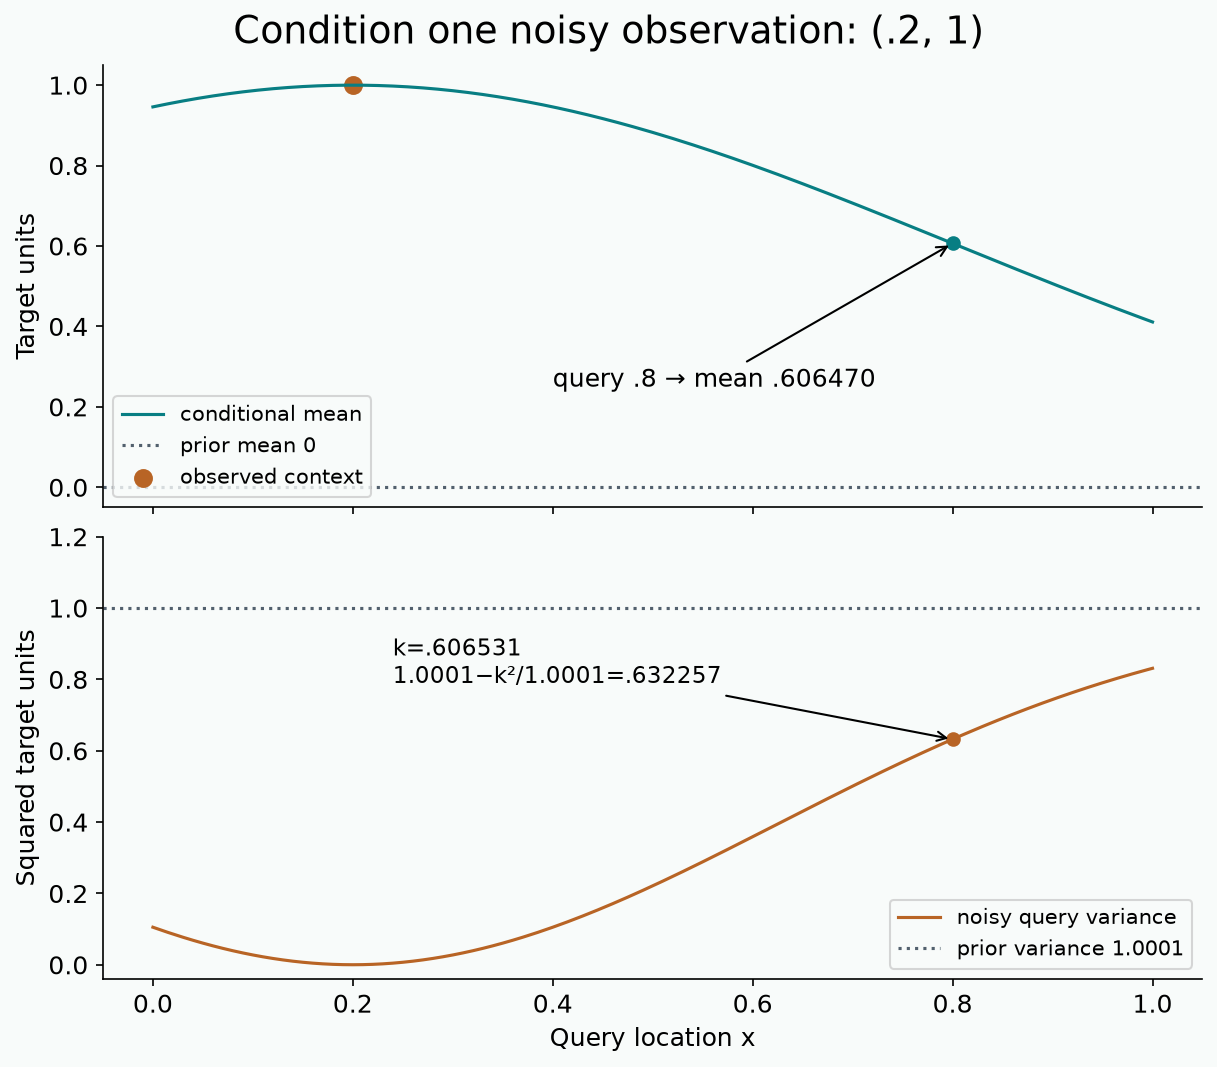" style="width:760px;min-width:640px;max-width:none;height:auto"></div>

Analytic one-observation fixture: context (.2, 1), length scale .6. Query .8 gives mean .606470 and noisy-target variance .632257. This is an exact GP computation, not a trained prediction. [Open full-size figure](figures/l061/conditioning-v2.png).

These formulas are the audit oracle, not an alternative neural training target. Their derivation and the distinction between latent-function and noisy-target prediction follow [Rasmussen and Williams, Chapter 2, equations 2.22–2.24 and Algorithm 2.1](https://gaussianprocess.org/gpml/chapters/RW2.pdf). In the HTML lesson, the widget above the figure holds the prior and observed target fixed while changing query distance; the portable image captures the default state.

## Why held-out likelihood learns the Bayesian answer

Denote the network parameters by `φ`, to distinguish them from a latent task. At each step sample a complete dataset from the prior, reveal context `D`, and train `qφ(y|x,D)` on sampled held-out targets. The **prior-data negative log likelihood**, or prior-data NLL, is the expected negative log density assigned to those targets:

```text
L(φ) = E[D,x,y] [−log qφ(y | x,D)]
     = E[D,x] ∫ p(y | x,D) [−log qφ(y | x,D)] dy
     = E[D,x] { H[p(· | x,D)] + KL[p(· | x,D) || qφ(· | x,D)] }
```

`H` is the predictive entropy (differential entropy for continuous targets). The **Kullback–Leibler divergence**, or KL, is the expected log density ratio under the first distribution. It is nonnegative. The entropy term does not depend on network weights, so reducing the population objective reduces expected forward KL. This is an expectation over the chosen prior, not a universal theorem about every possible dataset. Finite capacity, imperfect optimization, finite samples and a constrained output family all limit the actual approximation. The paper's optimum statement additionally assumes the target distribution belongs to the model family.

NLL is measured in natural-log units, or **nats**. For a continuous density it can be negative: a narrow density can exceed one per target unit while its integral is still one. Comparing NLL across incompatible target units is meaningless. We keep raw GP target units fixed. A finite test sample can even have a negative *measured* NLL difference relative to the oracle; nonnegative KL is a population statement, not a restriction on every sampled log ratio.

Every training step sees fresh sampled datasets. This removes repeated use of a finite pretraining table, but it does not make an individual minibatch loss a monotonic progress certificate, eliminate generator misspecification, or prevent overfitting a reused evaluation panel through manual choices. The local run fixes its recipe in advance, performs no test-based model selection, and reports the final weights. Larger compute runs are separate experiments.

### Why the same task must generate context and target

Consider the coin construction again. If the query uses a newly sampled, independent coin probability, conditioning on the context cannot change its predictive probability. A Beta(1,1) query remains Bernoulli(1/2) no matter how many context successes were observed. A learner could still optimize its training loss successfully, but the generator no longer asks it to infer a shared task.

For our GP, the analogous mistake is drawing a fresh latent function for the query. The full covariance becomes block diagonal between context and query: Kcq is zero, so Gaussian conditioning returns the prior mean and variance. The notebook executes a paired covariance check with correct joint draws and an independent-task query replacement. It is a check of generator semantics, not a second model-training comparison. Do not confuse it with shuffling context labels at inference: that intervention corrupts the evidence provided to an already trained predictor.

The important causal chain is therefore generator → joint distribution → conditional distribution → expected scoring-rule optimum. An impressive loss curve cannot repair the wrong first link. By contrast, feeding analytic posterior means as targets would preserve part of the desired answer but change the learning problem to supervised distillation. This lab deliberately trains on stochastic query labels, so the expected-objective argument does real work.

## Model architecture: the original row PFN

The current **RowPFN** implements the original released row Transformer. Let `B` be the number of independent tasks per batch, `N=n+m` total rows, `F` feature count, `d` embedding width, `H` attention heads, and `R` output bins. The lab uses `F=1, d=64, H=4, R=64`, three distinct blocks and an FFN hidden width of 128.

1. Project features with one shared affine map `Ex: F→d`. Project known scalar targets with `Ey: 1→d`. Context token `i` is `Ex(xi)+Ey(yi)`; a query token is only `Ex(xq)`. There is no fabricated zero target, unknown-label embedding or positional encoding in this variant. The forward signature accepts **only context labels**.
2. For each block, project tokens into query, key and value vectors, splitting width `d` into `H` heads of width `d/H`. Compute scaled dot products, add the access mask, apply a softmax over sending rows, and form a weighted sum of their value vectors. Concatenate heads and apply the output projection.
3. Apply the original **postnorm** residuals: `u=LayerNorm(h+attention(h))`, then `h'=LayerNorm(u+W2 GELU(W1u+b1)+b2)`. Layer normalization standardizes a token's coordinates and learns a scale and bias. GELU is a smooth nonlinear activation. Each block has its own parameters. The source clones one initialized block; its attention output projection and FFN second projection start at zero, allowing residual states to dominate initially.
4. Read the final query states through `Linear(d,128)→GELU→Linear(128,R)`. Softmax gives bin masses. A full-support Riemann distribution converts those masses into a probability density for real-valued targets. The loss is query NLL, not MSE of a point prediction.

<div style="overflow-x:auto;max-width:100%">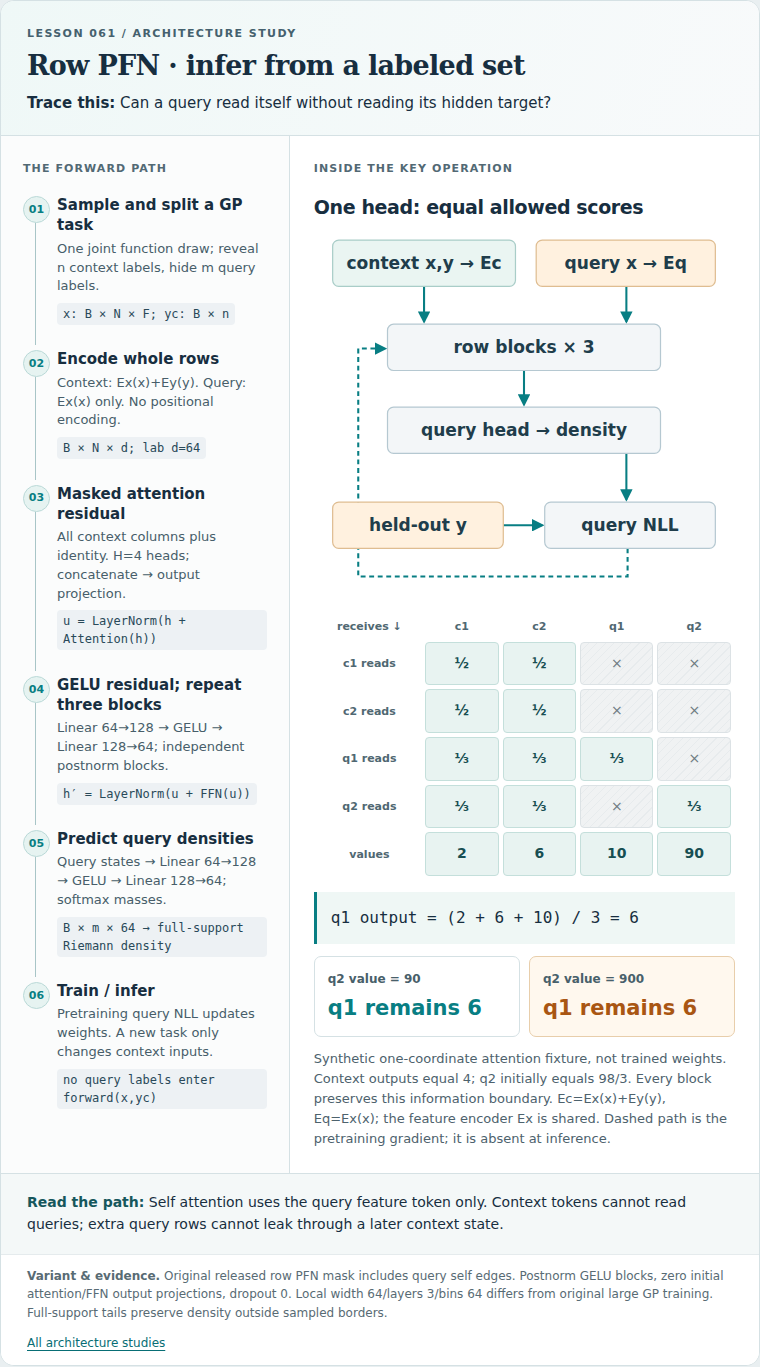</div>

*Portable architecture figure. On a narrow notebook screen, scroll horizontally to retain readable labels.* [Open the responsive diagram](https://avistian.github.io/relational/labs/html/architecture-review/0061-gppfn.html).

**Read the path:** Self attention uses the query feature token only. Context tokens cannot read queries; extra query rows cannot leak through a later context state.

**Variant and evidence:** Original released row PFN mask includes query self edges. Postnorm GELU blocks, zero initial attention/FFN output projections, dropout 0. Local width 64/layers 3/bins 64 differs from original large GP training. Full-support tails preserve density outside sampled borders.

The [pinned original Transformer source](https://github.com/automl/TransformersCanDoBayesianInference/blob/9c20031b355923bdd456d5fcfe4e98092b016b97/transformer.py) resolves a subtlety absent from the short paper description: its mask admits every context column **plus the diagonal**. A query can therefore read its own unlabeled feature representation as well as all context rows; it cannot read another query. A context cannot read any query. Self-attention is not target leakage because its target was never encoded. At `n=0`, each query reads itself, so attention remains defined.

Rows of an attention matrix are receivers; columns are senders. For two contexts and two queries, the allowed graph is:

```text
             c1  c2  q1  q2
c1 reads      ✓   ✓   ×   ×
c2 reads      ✓   ✓   ×   ×
q1 reads      ✓   ✓   ✓   ×
q2 reads      ✓   ✓   ×   ✓
```

This restriction must hold at **every block**. Otherwise query 2 could influence a context in block 1 and that context could influence query 1 in block 2, even if a direct query-to-query edge were absent. Without positional encodings, jointly permuting context feature/label pairs permutes context states and leaves query predictions unchanged, up to floating-point reduction differences. Independently shuffling targets breaks pairings and is not an invariance. Packing extra queries should leave a fixed query's prediction unchanged.

**Trace before running:** suppose allowed attention scores are all zero and one value coordinate is `[2,6,10,90]`. Context 1 reads `(2+6)/2=4`. Query 1 reads `(2+6+10)/3=6`. Changing the last value cannot change query 1. The notebook verifies those arithmetic and information-flow properties, then checks nonzero-branch copied-weight forward and gradient parity against the original implementation. That validates the named model computation, not the original training result.

## Turn bin masses into a continuous density

A regression head that emits only a mean loses predictive uncertainty. Even a Gaussian mean/variance head restricts the answer to one symmetric bell. The paper's **Riemann distribution** represents a density using many bars. Boundaries are chosen from prior-data target quantiles so that interior target intervals have roughly equal prior mass; network logits determine the masses for a particular context and query.

For an interior bin with edges `bi,bi+1`, width `wi=bi+1−bi`, and probability mass `pi`, its density is `pi/wi`. Distinguish probability from density: the chance of a continuous variable equaling exactly one real number is zero. Density integrates over an interval to yield probability. At a target in that bin the loss is `−log(pi)+log(wi)`.

A fixed bounded histogram assigns zero probability beyond its outer borders, which would give infinite NLL to possible Gaussian targets. The full-support head replaces its first and last bars by half-normal components. A **half-normal** is the nonnegative magnitude of a zero-mean normal variable. Anchor the left tail at the upper edge of the first nominal bin, the right tail at the lower edge of the last nominal bin, and reflect the left component toward negative infinity. If nominal tail width is `w`, set scale `s=w/.67448975`; then half of that component's mass lies within the nominal width.

```text
left density  = p0 × sqrt(2/π)/sL × exp(−(b1−y)²/(2sL²)), y ≤ b1
interior      = pi / wi
right density = pR−1 × sqrt(2/π)/sR × exp(−(y−bR−1)²/(2sR²))
```

Each component integrates to its softmax mass and the masses sum to one. The source's tail loss cancels the provisional width term and inserts the weighted half-normal log density. We retain those mixture weights; reading the typeset Appendix E.2 equation literally would miss them. Boundary assignment follows `searchsorted`'s left convention; isolated boundary points have zero probability, but tests cover them so code behavior is explicit.

For edges `[-3,-1,0,2,5]` and masses `[.1,.2,.3,.4]`, target `y=1` lies in a width-two interior bin. Its density is `.3/2=.15`, so NLL is `1.89712`. Using `.3` directly would incorrectly report `1.20397`. Targets beyond five remain possible under the right tail. Fixed bars cannot express arbitrary sharp within-bin peaks, and fixed tail scales cannot express arbitrary tail shapes: finite-bin approximation remains a real limitation even with perfect optimization.

### Three approximation errors can coexist

First, a finite density head imposes a representation error: a uniform interior bar cannot reproduce a Gaussian density that changes rapidly inside that bar. Second, finite optimization can fail to find even the best bin masses for the available architecture. Third, the held-out task sample estimates population performance with noise. These are distinct from prior mismatch, where the generator's intended Bayesian answer itself may be wrong for the application.

With fixed borders, the best categorical mass for a bin is its true posterior probability. That does not make the within-bin uniform density exact. With half-normal tails, there is an additional fixed component-shape restriction. More bins can reduce interior approximation error but increase output parameters, data requirements and numerical demands. Training longer does not automatically eliminate every kind of error.

The theorem about existence of increasingly fine Riemann distributions is not a finite-64-bin error bound. Also track KL direction: the population NLL decomposition uses KL(p || q), whereas the paper's finite-support approximation theorem is stated using KL(q || p). Substituting one for the other without conditions would be a mathematical mistake. For Gaussian targets a bounded-support q has infinite forward KL wherever p has positive tail mass; this motivates the full-support head in our actual likelihood experiment.

<div style="overflow-x:auto;max-width:100%" role="region" aria-label="Scrollable computation figure"><img alt="Synthetic full-support Riemann fixture. The interior target 1 has density .15 and NLL 1.89712. The first and last softmax masses multiply normalized half-normal tails." src="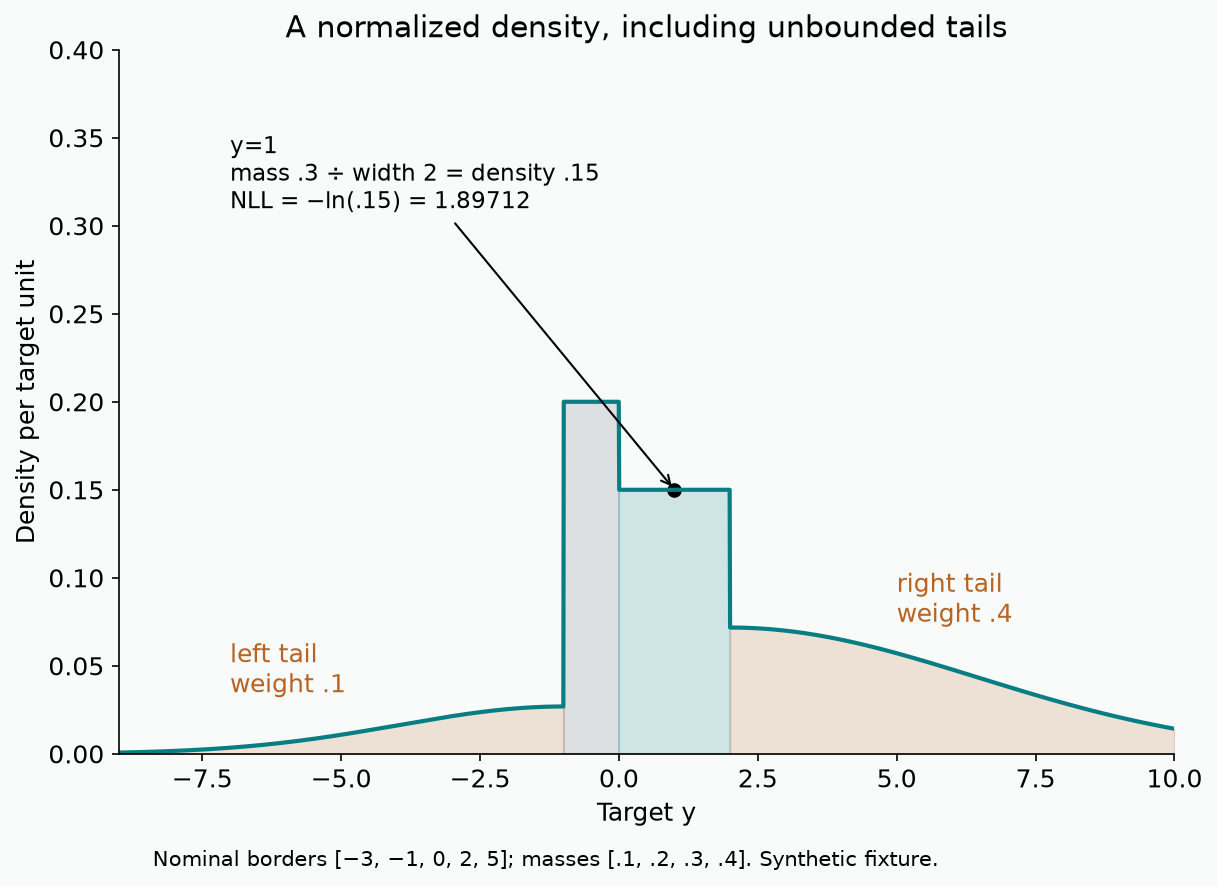" style="width:760px;min-width:640px;max-width:none;height:auto"></div>

Synthetic full-support Riemann fixture. The interior target 1 has density .15 and NLL 1.89712. The first and last softmax masses multiply normalized half-normal tails. [Open full-size figure](figures/l061/density-v2.png).

The model is unaware of a bar's width when predicting its mass. Widths and tail scales enter density scoring and summary calculations. Our borders use 65,536 independent draws from the known marginal `Normal(0,1.0001)` and remain fixed. The outer nominal borders are sampled extremes; after replacing tails, their nominal intervals no longer each integrate to exactly `1/R`. This is a density approximation, not an exact discretization of the GP posterior. See the [original full-support implementation](https://github.com/automl/TransformersCanDoBayesianInference/blob/9c20031b355923bdd456d5fcfe4e98092b016b97/bar_distribution.py).

## Fit on sampled tasks, evaluate against analysis

Before looking at results, predict two things: will this small PFN gain from context under its training prior, and will it match the almost-noiseless exact GP once several observations are available? These are different success criteria. Also predict what happens when test functions are much less smooth than the generator's functions.

The new author experiment uses three independent weight/training-task seeds, 2,000 Adam updates each, batch size 32 and total length 17. It samples context size `n=0,…,16` with weights proportional to `1/(17−n)` and trains on all remaining query labels. This follows the released context-size sampling idea; the loss averages queries per minibatch, as the released loop does. The learning rate warms up for 10% of steps and then decays by a cosine. No analytic mean, variance or probability is used as a training target.

For each context size `0,1,4,8,16,32`, evaluate 256 fresh GP tasks, each with one observed query target. The task stream is held fixed across training seeds, enabling paired comparisons. Context 32 is outside the maximum training context; it is a length-transfer probe. Repeat the panel with test length scale `.1`, while keeping the trained model at `.6`. This is a **prior-mismatch intervention**, not a second training run. The exact GP oracle is recalculated using the true test prior in each regime.

Report PFN NLL, exact noisy GP NLL, marginal-prior NLL, paired excess NLL, squared error of the PFN mean against the exact posterior mean, and central 95% predictive coverage. Coverage is the fraction of realized targets falling between the distribution's 2.5% and 97.5% quantiles, checked through its CDF. An uninformative but correctly calibrated prior can achieve good coverage while ignoring context; read it together with NLL and mean error.

<div style="overflow-x:auto;max-width:100%" role="region" aria-label="Scrollable computation figure"><img alt="New author reference: three training-seed points, shared 256 test tasks per context/regime. Exact GP, marginal prior and analytic masses in the same fixed head are diagnostic oracles. Both panels use the same y scale. No paper result reproduction." src="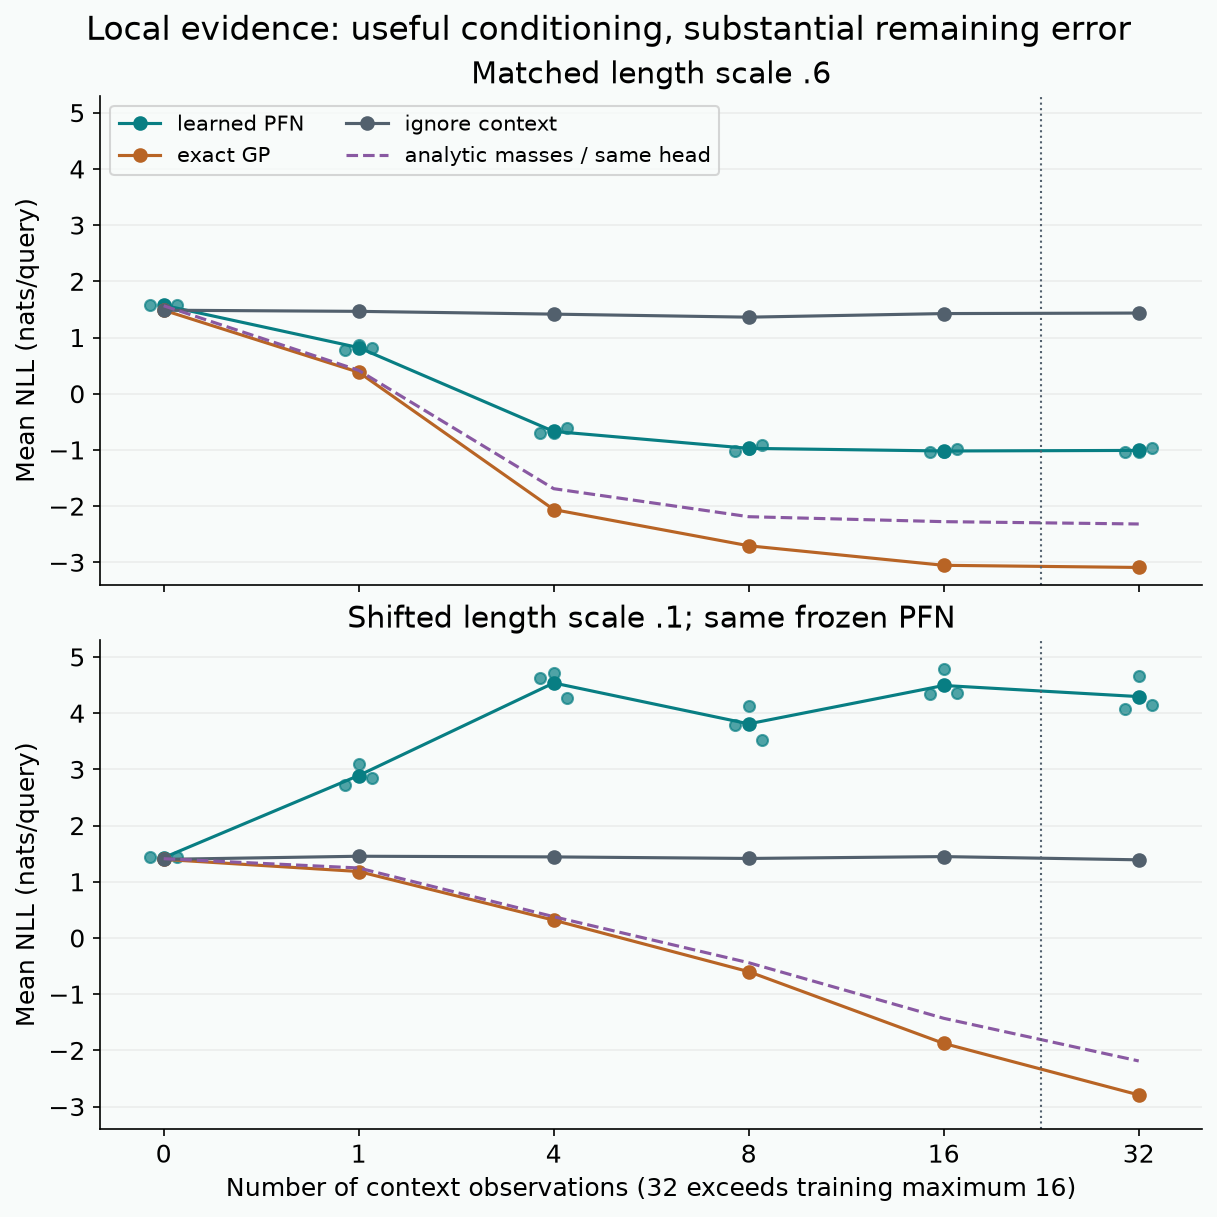" style="width:760px;min-width:640px;max-width:none;height:auto"></div>

New author reference: three training-seed points, shared 256 test tasks per context/regime. Exact GP, marginal prior and analytic masses in the same fixed head are diagnostic oracles. Both panels use the same y scale. No paper result reproduction. [Open full-size figure](figures/l061/results-v2.png).

<div style="overflow-x:auto;max-width:100%" role="region" aria-label="Scrollable computation figure"><img alt="Fresh trained seed 2, two chosen observations (.2,1) and(.8,−1). Central 95% predictive intervals are distribution intervals, not confidence intervals for a mean metric. Lower panel traces density at query .5." src="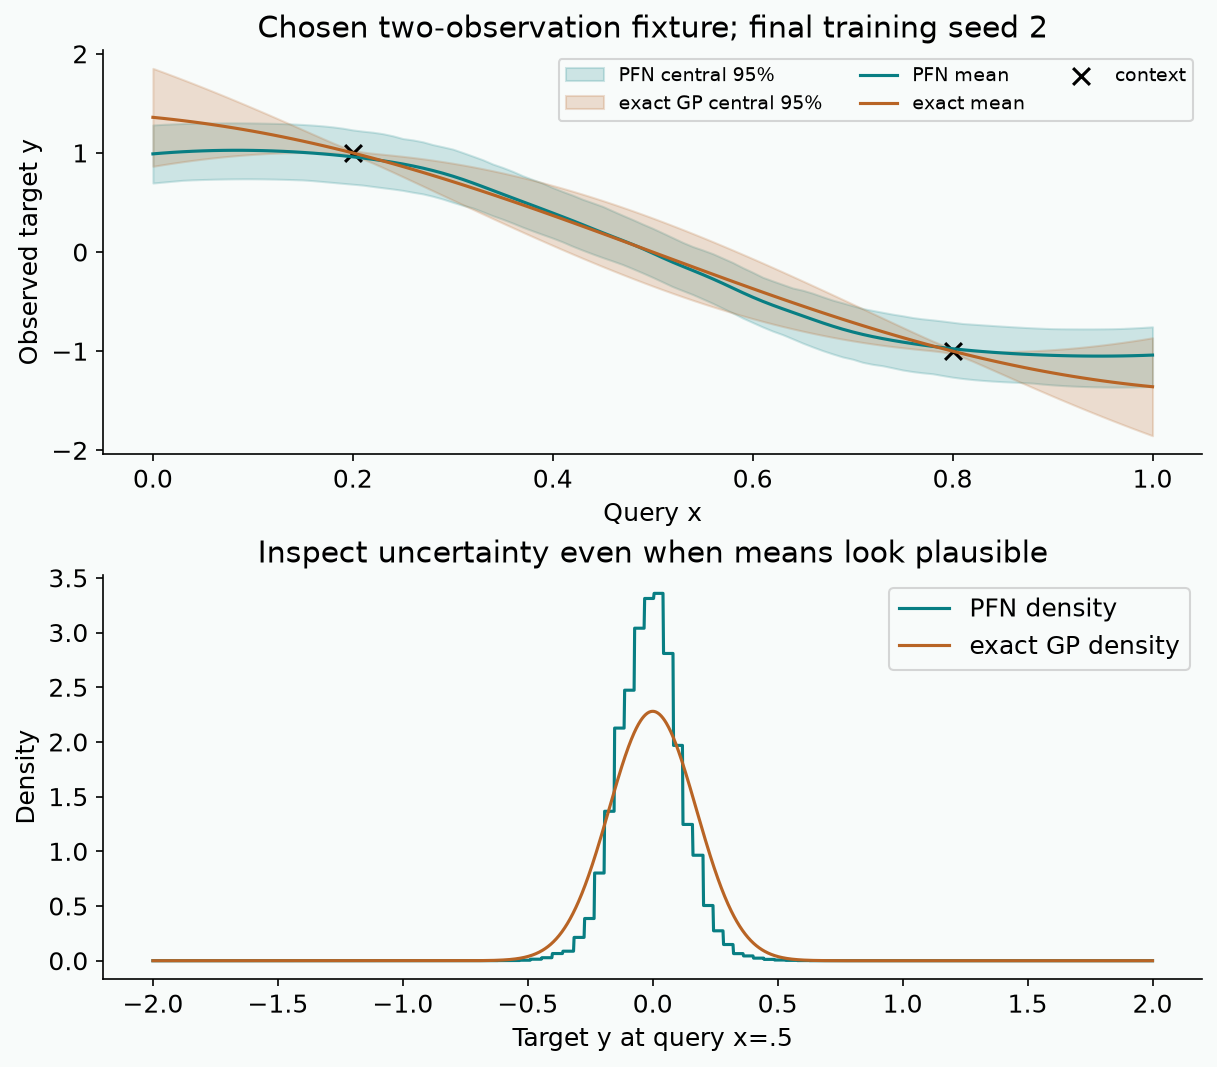" style="width:760px;min-width:640px;max-width:none;height:auto"></div>

Fresh trained seed 2, two chosen observations (.2,1) and(.8,−1). Central 95% predictive intervals are distribution intervals, not confidence intervals for a mean metric. Lower panel traces density at query .5. [Open full-size figure](figures/l061/predictions-v2.png).

**What actually happened:** at matched context size 16, mean PFN NLL was −1.0189, versus −3.0532 for the exact GP and 1.4258 for ignoring context. The model learned useful conditioning but remained 2.0342 nats/query behind the oracle. Its 100% measured central 95% coverage at this context size is consistent with overly broad predictions, not a reason to call it perfectly calibrated. Under length-scale shift, context 16 NLL rose to 4.4927 and coverage fell to 39.3%. The same fixed prior marginal is still appropriate without context because changing length scale changes correlations, not marginal variance.

A separate diagnostic puts **analytic GP probability masses into the identical 64-bin head**, without training a network. At matched context 16 its NLL is −2.2763: approximately .7769 nats above the exact GP, while the learned PFN is a further 1.2573 nats worse. This separates finite-head limitations from learned-mass error on these sampled tasks. It is not another trained baseline, and finite-sample differences are not universal lower bounds. [Diagnostic evidence](_analysis_l061_v2_results.json) records every context and regime.

The evidence table shows training-seed standard deviation over the same tasks. The paired task interval averages the log-ratio within a task over the three trained models, then uses a t interval across 256 independent tasks. It is conditional on these trained weights. It does not treat 768 reused-task predictions as independent tasks or establish generalization across real datasets. We preserve compressed raw input/target/logit arrays, oracle outputs, task seeds, library versions and source identities so the metrics can be reconstructed.

The curve fixes two observations, `(x=.2,y=1)` and `(x=.8,y=−1)`, and displays the final training seed's predictive mean. It is a chosen diagnostic fixture, separate from the random evaluation panel; it is not representative evidence by itself. The density and GP intervals show whether an apparently plausible mean still hides a poor uncertainty approximation. A deficient local approximation is a useful failure to diagnose, not evidence that the paper's much larger experiment failed.

## Compare where the information enters

An FT-Transformer from Lesson 050 makes **features within one row** into tokens; training labels update weights through its supervised loss. Other rows' labels are not a forward-pass input. This PFN instead makes **whole rows** into tokens and adds context labels directly to those tokens. Its main adaptation to a new dataset is an attention computation conditioned on those labeled rows. Mixing the two token axes would implement a different model even if both use the word Transformer.

SAINT in Lesson 047 also introduced communication across rows, but that alone does not make it a PFN. Its supervised training and optional pretraining use different objectives and data generation. The defining mechanism here is fitting held-out predictive distributions across independently sampled tasks, together with an information boundary that admits only the current context labels.

TabR in Lesson 052 retrieves labeled training examples through a learned representation and adds a learned correction to their label embeddings. It learns a task-specific predictor from the downstream dataset. The basic PFN instead learns a shared inference procedure before seeing that downstream dataset; it then conditions on context with frozen weights. Both can depend on context labels during a forward pass, but their optimization units and transfer assumptions differ. For a relational task, deciding what constitutes a context row or a sampled task is a substantive modeling choice, not a formatting detail.

## Exit: distinguish three kinds of success

The notebook's five live tasks implement the GP generator, Gaussian conditioning, access mask, attention aggregation and full-support density loss. Each task has a goal, reason, hint and immediate diagnostic CHECK. The entire model and training loop are visible. A fresh smoke calls those exact functions, while the larger author panel is clearly labeled reference evidence. You must save the live kernel's functions, class methods and preset values with your EXIT, not merely a hash of files elsewhere on disk.

Give three verdicts. **Operator validation:** did the Gaussian algebra, probability normalization, information-flow probes and copied-weight comparison pass? **Local learned approximation:** which contexts and regimes support useful conditioning, and how far is the trained model from the exact PPD? **Paper result reproduction:** the original Figure 4 study uses five features, much larger models, contexts approaching 2,000 and 1,000 evaluation datasets per context. Those results are cited, not reproduced here. Our `closer` operator increases features, context, width, bins and training budget; it is an executable step toward that target and remains explicitly different.

The source paper also studies hyperpriors over GP parameters, Bayesian neural-network priors, small real tabular classification and Omniglot few-shot learning. This unit's selected target is the fixed-GP study. It does not measure those other experiments or inherit their runtime and benchmark claims. Later TabPFN lessons change both the prior and task contract; a row-attention mechanism alone does not certify their pretrained models.

Write a teach-back explaining how a model trained on sampled labels can approximate an integral it never evaluates during training. Include one way that can fail, one observed metric, and one intervention that distinguishes a dead context path from prior mismatch. Ask the teacher about any unresolved step; a runnable EXIT and a cold explanation are required before assessing mastery. [Source inventory](_sources_l061_v2.json) and [reproduction commands](l061-reproduction.md) keep paper claims, local measurements and unrun work separate.

## Start the live implementation
Every mathematical operation below resolves in this notebook's namespace. Provided classes call your mask and attention functions; the trainer calls your sampler and loss; evaluation calls your GP oracle. Do not import replacement implementations to make the CHECKs pass. Each visible chunk is extracted from the versioned teaching module when this notebook is built.

In [ ]:
# PROVIDED — imports, path discovery and explicit local artifact folder
import base64,zlib,copy,hashlib,inspect,importlib.metadata,json,math,time,functools,sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from IPython.display import display
for path in [Path.cwd(),Path.cwd()/'labs',Path.cwd().parent]:
    if (path/'relkit').is_dir():ROOT=path.resolve();sys.path.insert(0,str(ROOT));break
else:raise RuntimeError('Run the course bootstrap or start inside labs')
__file__=str(ROOT/'relkit/pfn_l061_v2.py')  # repository reference identity only
output=ROOT/'data/cache/l061-student';output.mkdir(parents=True,exist_ok=True)
torch.set_num_threads(1)
VERSIONS={k:importlib.metadata.version(k) for k in ['numpy','torch','scipy']}
print(VERSIONS)

### PROVIDED · The signal covariance kernel
The last axis is features. Unsqueezing two row axes broadcasts each context location against each candidate location, yielding B×N×M squared distances. This is signal covariance; the sampler and oracle add noise to their own appropriate diagonal blocks.

In [ ]:
# PROVIDED — signal covariance
def rbf_kernel(x,z,lengthscale=.6):
    """Unit output variance; last axes are rows and numeric features."""
    if lengthscale<=0:raise ValueError('lengthscale must be positive')
    return torch.exp(-((x.unsqueeze(-2)-z.unsqueeze(-3))**2).sum(-1)/(2*lengthscale**2))

## TODO 1 · Draw one shared function

**Goal:** Return x:B×N×F and y:B×N. Sample uniform features, construct the noisy RBF covariance, factor in float64 and multiply a standard normal vector; return float32 on device. Reject nonpositive sizes/noise.

**Why:** The off-diagonal covariance is the information the context should reveal. Independent row targets remove it.

**Hint boundary:** rbf_kernel is provided. Keep all rows of a task in the same joint factorization and use the passed generator for both draws.

In [ ]:
# TODO — sample_gp
def sample_gp(batch,total,features,generator,lengthscale=.6,noise=1e-4,device='cpu'):
    raise NotImplementedError("Implement this live PFN operation")

In [ ]:
# CHECK — one jointly sampled GP, not independent row labels
_generator=torch.Generator().manual_seed(17)
_x,_y=sample_gp(12000,2,1,_generator)
assert _x.shape==(12000,2,1) and _y.shape==(12000,2)
_expected=rbf_kernel(_x,_x,.6)[:,0,1].mean().item()
assert abs((_y[:,0]*_y[:,1]).mean().item()-_expected)<.04, 'Context and query must share a GP draw'
assert abs(_y.var().item()-1.0001)<.04, 'Noise is variance added to K, not a replacement for task covariance'

### CHECK · Break the shared task deliberately
Predict the context/query covariance after replacing the query by a label from an independent GP task. This intervention preserves the marginal target distribution while removing shared-task information. The covariance check is not a trained negative-control PFN. Its analytic optimum would ignore context because the correct cross-covariance block is zero.

In [ ]:
# CHECK — executed independent-task generator negative control
x_joint,y_joint=sample_gp(12000,2,1,torch.Generator().manual_seed(120))
_,y_other=sample_gp(12000,2,1,torch.Generator().manual_seed(121))
joint_cov=float((y_joint[:,0]*y_joint[:,1]).mean())
broken_cov=float((y_joint[:,0]*y_other[:,1]).mean())
expected_cov=float(rbf_kernel(x_joint,x_joint)[:,0,1].mean())
assert abs(joint_cov-expected_cov)<.04 and abs(broken_cov)<.04
negative_control={'joint_covariance':joint_cov,'independent_query_covariance':broken_cov,'expected_joint':expected_cov}
print(negative_control)

## TODO 2 · Condition without an inverse

**Goal:** Return float64 mean and marginal variance of observed query targets. Handle empty context and reject incompatible shapes. Use a Cholesky solve; add observation noise only to the appropriate diagonal blocks.

**Why:** The independently computable oracle distinguishes an incorrect model from a poor approximation.

**Hint boundary:** Separate x into context/query blocks. The squared norm of a triangular solve gives the diagonal uncertainty reduction.

In [ ]:
# TODO — gp_posterior
def gp_posterior(x,context_y,n,lengthscale=.6,noise=1e-4):
    raise NotImplementedError("Implement this live PFN operation")

In [ ]:
# CHECK — one observation admits an independent scalar calculation
_x=torch.tensor([[[0.],[1.]]],dtype=torch.float64);_y=torch.tensor([[2.]],dtype=torch.float64)
_mu,_var=gp_posterior(_x,_y,1)
_k=math.exp(-1/(2*.6**2))
assert abs(_mu.item()-2*_k/1.0001)<1e-10, 'Solve Kcc against yc before multiplying Kqc'
assert abs(_var.item()-(1.0001-_k**2/1.0001))<1e-10, 'Predict noisy y: add query noise once'
_mu0,_v0=gp_posterior(_x,_y[:,:0],0)
assert torch.equal(_mu0,torch.zeros_like(_mu0)) and torch.allclose(_v0,torch.full_like(_v0,1.0001))

## TODO 3 · Enforce the information boundary

**Goal:** Return a total×total additive attention mask: zero where allowed, negative infinity elsewhere. Follow the original source including query self edges; reject n outside0…total−1.

**Why:** A wrong mask can leak across queries through an intermediate context token in later layers.

**Hint boundary:** Think in sending columns. Preserve the diagonal even when context is empty.

In [ ]:
# TODO — context_attention_mask
def context_attention_mask(total,n,device='cpu'):
    raise NotImplementedError("Implement this live PFN operation")

In [ ]:
# CHECK — rows receive, columns send; the original code keeps query self edges
_mask=context_attention_mask(4,2)
_expected=torch.tensor([[1,1,0,0],[1,1,0,0],[1,1,1,0],[1,1,0,1]],dtype=torch.bool)
assert torch.equal(torch.isfinite(_mask),_expected), 'Query self is allowed, another query is blocked'
assert torch.equal(torch.isfinite(context_attention_mask(3,0)),torch.eye(3,dtype=torch.bool)), 'Empty context uses unlabeled self only'

## TODO 4 · Perform one attention aggregation

**Goal:** For B×H×N×Dh projections, compute scaled dot products, masked row softmax and value aggregation. Return B×H×N×Dh.

**Why:** Softmax across receiving rows would normalize the wrong conditional weights while still producing plausible shapes.

**Hint boundary:** The final key dimension is the sender axis. Scaling uses one head’s width, not the full model width.

In [ ]:
# TODO — attention_mix
def attention_mix(q,k,v,mask):
    raise NotImplementedError("Implement this live PFN operation")

In [ ]:
# CHECK — masked scaled scores, row softmax and value aggregation
_q=torch.zeros(1,1,3,1);_k=_q.clone();_v=torch.tensor([[[[2.],[6.],[90.]]]])
_out=attention_mix(_q,_k,_v,context_attention_mask(3,2))
assert torch.allclose(_out.flatten(),torch.tensor([4.,4.,98/3])), 'Context reads two values; query reads them and itself'

### PROVIDED · Full row encoder and repeated postnorm blocks
Follow h:B×N×d through the qkv projection and head reshape. The concat after attention restores the original width; the two normalization calls occur after the additions. RowPFN constructs context tokens with actual labels and query tokens with features only. The head returns logits for query rows only. Both classes below use your live functions, including in copied-weight checks.

In [ ]:
# PROVIDED — complete attention/FFN block
class PFNBlock(nn.Module):
    """Visible postnorm TransformerEncoderLayer; dropout=0 for this mirror."""
    def __init__(self,width,heads,hidden):
        super().__init__()
        if width%heads:raise ValueError('Heads must divide width')
        self.heads=heads;self.width=width
        self.qkv=nn.Linear(width,3*width);self.out=nn.Linear(width,width)
        self.ff1=nn.Linear(width,hidden);self.ff2=nn.Linear(hidden,width)
        self.norm1=nn.LayerNorm(width);self.norm2=nn.LayerNorm(width)
        nn.init.xavier_uniform_(self.qkv.weight);nn.init.zeros_(self.qkv.bias)
        for layer in [self.out,self.ff2]:nn.init.zeros_(layer.weight);nn.init.zeros_(layer.bias)
    def forward(self,h,mask):
        b,n,d=h.shape
        q,k,v=self.qkv(h).reshape(b,n,3,self.heads,d//self.heads).permute(2,0,3,1,4).unbind(0)
        mixed=attention_mix(q,k,v,mask).transpose(1,2).reshape(b,n,d)
        h=self.norm1(h+self.out(mixed))
        return self.norm2(h+self.ff2(torch.nn.functional.gelu(self.ff1(h))))

In [ ]:
# PROVIDED — end-to-end row model
class RowPFN(nn.Module):
    """Whole rows are tokens; query labels never enter the forward signature."""
    def __init__(self,features=1,width=64,heads=4,hidden=128,layers=3,bins=64):
        super().__init__()
        self.x_encoder=nn.Linear(features,width);self.y_encoder=nn.Linear(1,width)
        block=PFNBlock(width,heads,hidden)
        # Original nn.TransformerEncoder clones one initialized template.
        self.blocks=nn.ModuleList([copy.deepcopy(block) for _ in range(layers)])
        self.head=nn.Sequential(nn.Linear(width,hidden),nn.GELU(),nn.Linear(hidden,bins))
    def forward(self,x,context_y):
        n=context_y.shape[1]
        if x.ndim!=3 or context_y.shape[0]!=x.shape[0] or n>=x.shape[1]:raise ValueError('Expected B×N×F x and B×n labels, n<N')
        h=self.x_encoder(x)
        h=torch.cat([h[:,:n]+self.y_encoder(context_y.unsqueeze(-1)),h[:,n:]],dim=1)
        mask=context_attention_mask(x.shape[1],n,x.device)
        for block in self.blocks:h=block(h,mask)
        return self.head(h[:,n:])

## TODO 5 · Score a full-support density

**Goal:** Return elementwise NLL matching y. Validate shapes and increasing borders, identify bins, combine log-softmax masses with interior log widths and normalized half-normal tails.

**Why:** A probability mass is not a density. Gaussian targets outside nominal borders must remain possible.

**Hint boundary:** Use stable log-softmax and searchsorted. The two tail components replace the uniform components; they do not add extra mixture mass.

In [ ]:
# TODO — riemann_nll
def riemann_nll(logits,y,borders):
    raise NotImplementedError("Implement this live PFN operation")

In [ ]:
# CHECK — density is mass / width; tails integrate to their assigned mass
_b=torch.tensor([-3.,-1.,0.,2.,5.],dtype=torch.float64)
_logits=torch.log(torch.tensor([[.1,.2,.3,.4]],dtype=torch.float64))
assert abs(riemann_nll(_logits,torch.tensor([1.],dtype=torch.float64),_b).item()+math.log(.3/2))<1e-12
_tail=riemann_nll(_logits,torch.tensor([12.],dtype=torch.float64),_b)
assert torch.isfinite(_tail).all(), 'Unbounded GP targets need nonzero tail density'
assert torch.allclose(riemann_nll(_logits+100,torch.tensor([1.],dtype=torch.float64),_b),riemann_nll(_logits,torch.tensor([1.],dtype=torch.float64),_b))

## PROVIDED · From logits to means and central coverage
make_borders uses an independent marginal-prior sample with seed 731. It never fits a boundary using held-out query labels. riemann_mean accounts for the means of the two half-normal tails; riemann_cdf integrates each component before weighting. A plain midpoint average would use the wrong tail means. Read these functions even though they are provided.

In [ ]:
# PROVIDED — make_borders
def make_borders(bins,seed=731,samples=65536):
    """Prior marginal quantiles, never fitted on evaluation labels. See tail caveat."""
    generator=torch.Generator().manual_seed(seed)
    ys=torch.randn(samples,generator=generator)*math.sqrt(1.0001)
    return torch.quantile(ys,torch.linspace(0,1,bins+1))

In [ ]:
# PROVIDED — riemann_mean
def riemann_mean(logits,borders):
    widths=borders[1:]-borders[:-1];means=(borders[1:]+borders[:-1])/2
    median=math.sqrt(2)*torch.erfinv(borders.new_tensor(.5))
    means=means.clone();means[0]=borders[1]-widths[0]/median*math.sqrt(2/math.pi)
    means[-1]=borders[-2]+widths[-1]/median*math.sqrt(2/math.pi)
    return logits.softmax(-1)@means

In [ ]:
# PROVIDED — riemann_cdf
def riemann_cdf(logits,y,borders):
    """Integrate each normalized component; useful for central coverage and plots."""
    widths=borders[1:]-borders[:-1]
    fractions=((y.unsqueeze(-1)-borders[:-1])/widths).clamp(0,1)
    median=math.sqrt(2)*torch.erfinv(borders.new_tensor(.5))
    fractions[...,0]=1-torch.erf(((borders[1]-y).clamp(min=0))/(widths[0]/median*math.sqrt(2)))
    fractions[...,-1]=torch.erf(((y-borders[-2]).clamp(min=0))/(widths[-1]/median*math.sqrt(2)))
    return (logits.softmax(-1)*fractions).sum(-1)

## CHECK · Validate the live model against the original implementation
The validation harness downloads pinned source files into an isolated cache; it does not install a model package. It copies nonzero weights into the model you just defined, checks float32 and float64 outputs, mapped parameter/input gradients, target-density values/gradients, context permutation and query independence. A same-valued float64 mask is passed explicitly to the reference in float64 tests; production float32 also uses the original implicit mask. This validates the named computation, not original optimizer trajectories or benchmark scores.

In [ ]:
# CHECK — reference library/source is a validation point; your live definitions are the subject
from _check_l061_v2 import check as validate_live_pfn
parity=validate_live_pfn(globals(),save=False)
print({key:value for key,value in parity.items() if key!='official_sources'})

## PROVIDED · Fresh-task pretraining and paired evaluation
The trainer contains no call to gp_posterior: it sees sampled labels only. The evaluator freezes the network, then uses your oracle for each matched or shifted task. The task batches, targets, logits and analytic moments are preserved in compressed arrays; this keeps independent reconstruction possible. Each selected evaluation context has one query and the same task stream across weight seeds.

In [ ]:
# PROVIDED — exact declared budgets
PRESETS={'smoke': {'steps': 30, 'batch': 16, 'total': 12, 'features': 1, 'width': 32, 'heads': 4, 'hidden': 64, 'layers': 2, 'bins': 32, 'lr': 0.001, 'seeds': [0], 'eval_tasks': 32, 'contexts': [0, 1, 4, 8, 16]}, 'lab': {'steps': 2000, 'batch': 32, 'total': 17, 'features': 1, 'width': 64, 'heads': 4, 'hidden': 128, 'layers': 3, 'bins': 64, 'lr': 0.0003, 'seeds': [0, 1, 2], 'eval_tasks': 256, 'contexts': [0, 1, 4, 8, 16, 32]}, 'closer': {'steps': 10000, 'batch': 32, 'total': 65, 'features': 5, 'width': 128, 'heads': 4, 'hidden': 256, 'layers': 6, 'bins': 256, 'lr': 0.0003, 'seeds': [0, 1, 2], 'eval_tasks': 1000, 'contexts': [0, 1, 4, 16, 32, 64, 128]}}

In [ ]:
# PROVIDED — train_pfn
def train_pfn(config,seed,device='cpu'):
    """Algorithm 1: independent fresh datasets; sampled y targets only, never PPD."""
    torch.manual_seed(seed);generator=torch.Generator().manual_seed(seed+10000)
    model=RowPFN(**{k:config[k] for k in ['features','width','heads','hidden','layers','bins']}).to(device)
    borders=make_borders(config['bins']).to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=config['lr'])
    total=config['total'];weights=1/torch.arange(total,0,-1,dtype=torch.float32)
    trace=[];start=time.perf_counter();model.train()
    for step in range(config['steps']):
        n=int(torch.multinomial(weights,1,generator=generator))
        x,y=sample_gp(config['batch'],total,config['features'],generator,device=device)
        warmup=max(1,config['steps']//10)
        factor=min((step+1)/warmup,1.)*.5*(1+math.cos(math.pi*max(0,step-warmup)/max(1,config['steps']-warmup)))
        for group in optimizer.param_groups:group['lr']=config['lr']*factor
        logits=model(x,y[:,:n]);loss=riemann_nll(logits,y[:,n:],borders).mean()
        if not torch.isfinite(loss):raise ArithmeticError('Nonfinite training likelihood')
        optimizer.zero_grad();loss.backward();nn.utils.clip_grad_norm_(model.parameters(),1.);optimizer.step()
        if step==0 or (step+1)%max(1,config['steps']//10)==0:
            trace.append(dict(step=step+1,n_context=n,nll=loss.item(),lr=group['lr']))
    return model.eval(),borders,trace,time.perf_counter()-start

In [ ]:
# PROVIDED — encode_tensor
def encode_tensor(tensor):
    array=tensor.detach().cpu().contiguous().numpy()
    return dict(shape=list(array.shape),dtype=str(array.dtype),zlib_base64=base64.b64encode(zlib.compress(array.tobytes())).decode(),sha256=hashlib.sha256(array.tobytes()).hexdigest())

In [ ]:
# PROVIDED — evaluate_pfn
def evaluate_pfn(model,borders,config,seed):
    """Fixed independent evaluation task stream, paired across training seeds."""
    records=[];device=next(model.parameters()).device
    with torch.no_grad():
        for lengthscale,regime in [(.6,'matched'),(.1,'prior_shift')]:
            for n in config['contexts']:
                generator=torch.Generator().manual_seed(20000+n+(1000 if regime=='prior_shift' else 0))
                audit=[]
                values={k:[] for k in ['pfn_nll','gp_nll','prior_nll','mean_squared_error','coverage95','excess_nll']}
                for start in range(0,config['eval_tasks'],64):
                    batch=min(64,config['eval_tasks']-start)
                    x,y=sample_gp(batch,n+1,config['features'],generator,lengthscale=lengthscale,device=device)
                    logits=model(x,y[:,:n]);mu,var=gp_posterior(x,y[:,:n],n,lengthscale)
                    target=y[:,n:].double();pfn=riemann_nll(logits,y[:,n:],borders).double()
                    gp=.5*(torch.log(2*math.pi*var)+(target-mu)**2/var)
                    prior=.5*(math.log(2*math.pi*1.0001)+target**2/1.0001)
                    cdf=riemann_cdf(logits,y[:,n:],borders)
                    outputs=dict(pfn_nll=pfn,gp_nll=gp,prior_nll=prior,mean_squared_error=(riemann_mean(logits,borders)-mu)**2,coverage95=((cdf>=.025)&(cdf<=.975)).double(),excess_nll=pfn-gp)
                    for key,value in outputs.items():values[key]+=value.flatten().cpu().tolist()
                    audit.append({key:encode_tensor(value) for key,value in dict(x=x,y=y,logits=logits,gp_mean=mu,gp_variance=var).items()})
                records.append(dict(seed=seed,regime=regime,n_context=n,task_seed=20000+n+(1000 if regime=='prior_shift' else 0),audit_batches=audit,task_values=values,**{k:float(np.mean(v)) for k,v in values.items()}))
    return records

In [ ]:
# PROVIDED — summarize_records
def summarize_records(records):
    """Seed SD and paired-task intervals answer different questions; retain both."""
    from scipy.stats import t
    summaries=[]
    for regime,n in sorted({(r['regime'],r['n_context']) for r in records}):
        rows=[r for r in records if (r['regime'],r['n_context'])==(regime,n)]
        detail=dict(regime=regime,n_context=n,seeds=[r['seed'] for r in rows])
        for metric in ['pfn_nll','gp_nll','prior_nll','mean_squared_error','coverage95','excess_nll']:
            seed_values=np.array([r[metric] for r in rows]);tasks=np.array([r['task_values'][metric] for r in rows]).mean(0)
            detail[metric]=dict(mean=float(seed_values.mean()),seed_sd=float(seed_values.std(ddof=1)) if len(rows)>1 else None,conditional_task_t95=float(t.ppf(.975,len(tasks)-1)*tasks.std(ddof=1)/math.sqrt(len(tasks))),seed_values=seed_values.tolist())
        summaries.append(detail)
    return summaries

In [ ]:
# PROVIDED — state_hash
def state_hash(model):
    h=hashlib.sha256()
    for name,value in model.state_dict().items():h.update(name.encode());h.update(value.detach().cpu().contiguous().numpy().tobytes())
    return h.hexdigest()

In [ ]:
# PROVIDED — run_experiment
def run_experiment(preset='lab',output=None,device='cpu'):
    """No resume or result overwrite. Notebook replaces repository identity explicitly."""
    if preset=='paper':raise ValueError('Full original Fig4 protocol is not implemented; closer is a documented scale step')
    if preset not in PRESETS:raise ValueError('Choose smoke, lab or closer')
    output=Path(output) if output is not None else None
    if output is not None and output.exists():raise FileExistsError('Choose a fresh evidence path')
    config=copy.deepcopy(PRESETS[preset]);records=[];runs=[];start=time.perf_counter();torch.set_num_threads(1)
    for seed in config['seeds']:
        model,borders,trace,seconds=train_pfn(config,seed,device)
        records+=evaluate_pfn(model,borders,config,seed)
        runs.append(dict(seed=seed,training_seconds=seconds,trace=trace,weights_sha256=state_hash(model)))
        print(f'L061 {preset} seed {seed}: {seconds:.1f}s training',flush=True)
    # Persist a transparent two-observation prediction trace for the portable figure.
    with torch.no_grad():
        grid=torch.linspace(0,1,101,device=device).view(1,-1,1).repeat(1,1,config['features'])
        context=torch.tensor([.2,.8],device=device).view(1,2,1).repeat(1,1,config['features'])
        x=torch.cat([context,grid],1);cy=torch.tensor([[1.,-1.]],device=device)
        logits=model(x,cy);mu,var=gp_posterior(x,cy,2)
        curve=dict(training_seed=config['seeds'][-1],context_x=[.2,.8],context_y=[1.,-1.],grid=grid[0,:,0].cpu().tolist(),logits=logits[0].cpu().tolist(),gp_mean=mu[0].cpu().tolist(),gp_variance=var[0].cpu().tolist(),pfn_mean=riemann_mean(logits,borders)[0].cpu().tolist())
    result=dict(status='COMPLETE',operator='pfn_l061_v2',preset=preset,config=config,prior=dict(kernel='RBF',lengthscale=.6,noise_variance=1e-4,output_variance=1.,x='Uniform unit cube'),runs=runs,records=records,summary=summarize_records(records),borders=borders.cpu().tolist(),curve=curve,seconds=time.perf_counter()-start,versions={k:importlib.metadata.version(k) for k in ['numpy','torch','scipy']},paper_reproduction='INCOMPARABLE',repository_reference_sha256=hashlib.sha256(Path(__file__).read_bytes()).hexdigest(),source_hashes_scope='Repository reference file; notebook actual kernel source is captured separately',uncertainty='Training-seed SD over fixed tasks; paired task t interval conditional on these trained seeds; tasks shared across training seeds',deviations=[f"{config['features']} input features vs 5 in Fig4",f"width{config['width']}/layers{config['layers']}/bins{config['bins']} vs released width512/layers6/bins1000 or10000",f"{config['steps']} updates per seed; N{config['total']} not N2010",f"{config['eval_tasks']} evaluation tasks vs1000",'sampled marginal quantile borders; 10percent warmup per step','No MCMC/VI/BNN/tabular/Omniglot replication'])
    if output is not None:output.parent.mkdir(parents=True,exist_ok=True);output.write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
    return result

### PROVIDED · Capture the code actually executed
A repository hash labels author reference code. This kernel can contain edited functions and class methods that differ from it. The identity below records all visible sampler/model/density/evaluator/helper source texts, including methods and PRESETS, plus library versions. There is no checkpoint resume; an existing run filename is rejected. The mutation check changes both a helper and a class method, then restores them.

In [ ]:
# PROVIDED — actual kernel source identity
KERNEL_NAMES=['rbf_kernel', 'sample_gp', 'gp_posterior', 'context_attention_mask', 'attention_mix', 'PFNBlock', 'RowPFN', 'make_borders', 'riemann_nll', 'riemann_mean', 'riemann_cdf', 'train_pfn', 'encode_tensor', 'evaluate_pfn', 'summarize_records', 'state_hash', 'run_experiment']
def normalize_default(value):
    if value is None or isinstance(value,(str,int,float,bool)):return value
    if isinstance(value,(list,tuple)):return [normalize_default(v) for v in value]
    if isinstance(value,dict):return {str(k):normalize_default(v) for k,v in value.items()}
    if inspect.isfunction(value):return {'function_source':inspect.getsource(value),'defaults':normalize_default(value.__defaults__),'kwdefaults':normalize_default(value.__kwdefaults__)}
    raise TypeError('Unsupported live default; record it explicitly rather than using an unstable repr')

def capture_kernel_identity():
    sources={};defaults={}
    for name in KERNEL_NAMES:
        obj=inspect.unwrap(globals()[name])
        if inspect.isclass(obj):
            sources[name]={method:inspect.getsource(value) for method,value in vars(obj).items() if inspect.isfunction(value)}
            defaults[name]={method:{'defaults':normalize_default(value.__defaults__),'kwdefaults':normalize_default(value.__kwdefaults__)} for method,value in vars(obj).items() if inspect.isfunction(value)}
        else:
            sources[name]=inspect.getsource(obj)
            defaults[name]={'defaults':normalize_default(obj.__defaults__),'kwdefaults':normalize_default(obj.__kwdefaults__)}
    content={'sources':sources,'defaults':defaults,'default_normalizer_source':inspect.getsource(normalize_default),'presets':copy.deepcopy(PRESETS),'versions':dict(VERSIONS),'capture_source':inspect.getsource(capture_kernel_identity)}
    content['sha256']=hashlib.sha256(json.dumps(content,sort_keys=True).encode()).hexdigest()
    return content

def attach_kernel_identity(result,path):
    result['repository_source_hashes_are_reference_only']=True
    result['kernel_identity']=capture_kernel_identity()
    Path(path).write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
    return result

In [ ]:
# CHECK — source/default/class-method edits are visible; restore everything afterward
before=capture_kernel_identity()['sha256']
original_kernel=rbf_kernel
original_forward=RowPFN.forward
original_defaults=rbf_kernel.__defaults__
original_steps=PRESETS['smoke']['steps']
def altered_kernel(x,z,lengthscale=.6):
    return original_kernel(x,z,lengthscale)+.1
def altered_forward(self,x,context_y):
    return original_forward(self,x,context_y)+.1
try:
    rbf_kernel=altered_kernel
    assert capture_kernel_identity()['sha256']!=before
    rbf_kernel=original_kernel;rbf_kernel.__defaults__=(.7,)
    assert capture_kernel_identity()['sha256']!=before
    rbf_kernel.__defaults__=original_defaults;RowPFN.forward=altered_forward
    assert capture_kernel_identity()['sha256']!=before
    RowPFN.forward=original_forward;PRESETS['smoke']['steps']+=1
    assert capture_kernel_identity()['sha256']!=before
finally:
    rbf_kernel=original_kernel;rbf_kernel.__defaults__=original_defaults;RowPFN.forward=original_forward;PRESETS['smoke']['steps']=original_steps
assert capture_kernel_identity()['sha256']==before
print('Live helper, class method and preset changes detected and restored; no resume supported')

## Run the fresh smoke through all five tasks
Thirty updates test execution and wiring; they cannot establish a learned posterior approximation. The saved author panel uses 2000 updates per seed and is examined next. The wrapped call counters instrument the actual names used inside the provided model, trainer and evaluator. Only after restoring the wrappers do we capture the final source identity.

In [ ]:
# PROVIDED — bounded fresh fit, actual live call counts, no result overwrite
names=['sample_gp','gp_posterior','context_attention_mask','attention_mix','riemann_nll']
originals={name:globals()[name] for name in names};calls={name:0 for name in names}
def counted(name,function):
    @functools.wraps(function)
    def wrapper(*args,**kwargs):
        calls[name]+=1
        return function(*args,**kwargs)
    return wrapper
for name,function in originals.items():globals()[name]=counted(name,function)
try:
    fresh_path=output/f'smoke-{time.time_ns()}.json'
    fresh=run_experiment('smoke',fresh_path)
finally:
    for name,function in originals.items():globals()[name]=function
assert all(value>0 for value in calls.values()),'Every live TODO must reach the fresh experiment'
attach_kernel_identity(fresh,fresh_path)
print('Actual calls:',calls)
display(pd.DataFrame([{key:r[key] for key in ['seed','regime','n_context','pfn_nll','gp_nll','excess_nll']} for r in fresh['records']]))

## Train your completed PFN, not just the smoke
Now fit a genuinely learned model through your live implementation: the lab recipe uses 2000 updates, but this student run uses seed 7 only. That is a fresh trained model, not the author seed 0–2 models. Its evaluation tasks are deliberately the same declared panel, making comparisons conditional on that panel; do not select a new recipe by repeatedly inspecting it. Expect roughly a minute or two on the author CPU, with runtime varying by host. The saved model-state hash, training trace, raw predictions and kernel source identify this run.

In [ ]:
# PROVIDED — substantive default learning run; one explicit new training seed
student_config=copy.deepcopy(PRESETS['lab']);student_config['seeds']=[7]
student_model,student_borders,student_trace,student_seconds=train_pfn(student_config,7)
student_records=evaluate_pfn(student_model,student_borders,student_config,7)
learned={'status':'COMPLETE','operator':'pfn_l061_v2-student','config':student_config,
 'prior':fresh['prior'],'versions':VERSIONS,'seed':7,'training_seconds':student_seconds,
 'trace':student_trace,'weights_sha256':state_hash(student_model),'records':student_records,
 'summary':summarize_records(student_records),'borders':student_borders.tolist(),'paper_reproduction':'INCOMPARABLE'}
learned_path=output/f'fit-seed7-{time.time_ns()}.json'
attach_kernel_identity(learned,learned_path)
display(pd.DataFrame([{key:r[key] for key in ['seed','regime','n_context','pfn_nll','gp_nll','prior_nll','coverage95']} for r in student_records]))
print('Fresh learned PFN seed 7 saved:',learned_path,'Training seconds:',student_seconds)
print('One training seed: no training-seed uncertainty estimate. Original paper results not reproduced.')

## Read author reference evidence without calling it your result
The table below loads the three-seed measured panel. NLL is lower-is-better; coverage is a calibration diagnostic with a 95% target, not a higher-is-always-better score. Mean squared error compares predictive means to the analytic mean, not to noisy labels. The accompanying diagnostic supplies exact GP region masses to the same fixed head: it isolates head restrictions from learned mass errors, without training another network.

In [ ]:
# PROVIDED — transparent author-reference tables, separate from fresh smoke
reference_path=ROOT/'_verify_l061_v2_results.json'
reference=json.loads(reference_path.read_text())
head_diagnostic=json.loads((ROOT/'_analysis_l061_v2_results.json').read_text())
assert head_diagnostic['evidence_sha256']==hashlib.sha256(reference_path.read_bytes()).hexdigest()
rows=[]
for row in reference['summary']:
    rows.append({'regime':row['regime'],'context':row['n_context'],
      'PFN mean':row['pfn_nll']['mean'],'seed SD':row['pfn_nll']['seed_sd'],
      'exact GP':row['gp_nll']['mean'],'excess':row['excess_nll']['mean'],
      'paired task ±95%':row['excess_nll']['conditional_task_t95'],
      'mean MSE':row['mean_squared_error']['mean'],'coverage95':row['coverage95']['mean']})
display(pd.DataFrame(rows).round(5))
display(pd.DataFrame(head_diagnostic['records']).round(5))
print('Training traces are sampled minibatch NLL, not monotonic validation curves.')
print('Reference operator SHA:',reference['repository_reference_sha256'])
print('Current live code SHA:',capture_kernel_identity()['sha256'])

## EXIT TICKET · State what the experiment establishes
In at least 120words, explain the shared-task generator, why self-query attention is legal, why probability masses need density conversion, and why the population objective does not certify this learned PFN. Report one matched and one shifted result with their context sizes. Distinguish the fixed-head oracle from the exact GP and the trained network. Distinguish your fresh 30-step smoke, your fresh 2000-step seed 7 fit, and the author three-seed result. Save the live code identity and the three verdicts. Submit the resulting JSON and your explanation to the teacher.

In [ ]:
# EXIT — replace with your own explanation
local_verdict='WRITE YOUR OBSERVED VERDICT'
interpretation='WRITE YOUR OWN EXPLANATION HERE'
assert 'WRITE' not in local_verdict,'Supply a verdict supported by your actual seed 7 metrics'
assert len(interpretation.split())>=120,'Explain the mechanism, measured gaps and evidence boundary in at least 120 words'
exit_report={'lesson':61,'operator_validation':parity,'live_call_counts':calls,'generator_negative_control':negative_control,
 'fresh_smoke':str(fresh_path),'fresh_learned':str(learned_path),'student_summary':learned['summary'],'student_config':student_config,'author_reference_sha256':hashlib.sha256(reference_path.read_bytes()).hexdigest(),
 'author_summary':rows,'kernel_identity':capture_kernel_identity(),'interpretation':interpretation,
 'verdicts':{'operator':'PASS','local_approximation':local_verdict,'author_reference':'USEFUL_CONDITIONING_WITH_SUBSTANTIAL_GAPS','paper_results':'INCOMPARABLE'}}
exit_path=output/'exit.json'
if exit_path.exists():exit_path=output/f'exit-{time.time_ns()}.json'
exit_path.write_text(json.dumps(exit_report,indent=2,allow_nan=False)+'\n')
print('Saved EXIT:',exit_path)
print(exit_report['verdicts'])

## NEXT STEP · Train closer to the selected paper study
This required follow-up is an explicit runnable track with the same visible implementation. First run `lab` to reproduce the local three-seed result. Then `closer` uses five features, 6 blocks,128 width,256 bins,65 total rows,10000 updates and 1000 held-out tasks per context. The paper's released large-GP setup is much bigger and has recipe ambiguities documented in the reproduction contract. `paper` raises instead of silently claiming fidelity. The gate below is off; attach a suitable GPU before explicitly enabling the larger run. The Modal wrapper is separately supplied and has not been run. A full original-paper claim requires protocol alignment and a fresh result comparison, not just finishing this cell.

In [ ]:
# PROVIDED — explicit post-EXIT Colab scale-up; no automatic cloud work
RUN_PAPER_REPRO=False
REPRO_PRESET='closer'
if RUN_PAPER_REPRO:
    repro_device='cuda' if torch.cuda.is_available() else 'cpu'
    larger_path=output/f'{REPRO_PRESET}-{time.time_ns()}.json'
    larger=run_experiment(REPRO_PRESET,larger_path,repro_device)
    attach_kernel_identity(larger,larger_path)
    print('Verified here: this explicit GP run. Paper claim: cited. Scale-up: INCOMPARABLE to original Figure4.')
else:print('Scale-up NOT_RUN in this kernel; original Figure4 reproduction remains INCOMPARABLE.')